In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [25]:
df = pd.read_csv('Advertising.csv')

In [26]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [27]:
X_simple = df[['TV']]

In [28]:
X_multiple = df[['TV', 'Radio', 'Newspaper']]


In [29]:
y = df['Sales']

In [30]:
#traing testing split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)


In [31]:
# multiple model split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)


In [32]:
# Simple Linear Regression
simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# prediction
y_pred_simple = simple_model.predict(X_test_s)


In [34]:
multiple_model = LinearRegression()

multiple_model.fit(X_train_m, y_train_m)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
# Predictions
y_pred_multiple = multiple_model.predict(X_test_m)

In [36]:
#  Evaluation Metrics


# Simple Model
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

# Multiple Model
mse_multiple = mean_squared_error(y_test_m, y_pred_multiple)
r2_multiple = r2_score(y_test_m, y_pred_multiple)


In [37]:
print("\n===== Simple Linear Regression =====")
print("MSE:", mse_simple)
print("R2 Score:", r2_simple)

print("\n===== Multiple Linear Regression =====")
print("MSE:", mse_multiple)
print("R2 Score:", r2_multiple)



===== Simple Linear Regression =====
MSE: 10.204654118800956
R2 Score: 0.6766954295627076

===== Multiple Linear Regression =====
MSE: 3.1740973539761033
R2 Score: 0.899438024100912


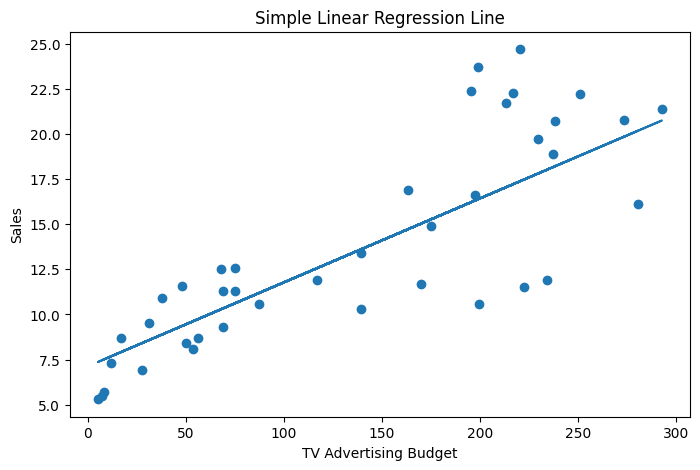

In [38]:
# Regression line visualization
plt.figure(figsize=(8,5))

plt.scatter(X_test_s, y_test_s)

plt.plot(X_test_s, y_pred_simple)

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("Simple Linear Regression Line")

plt.show()

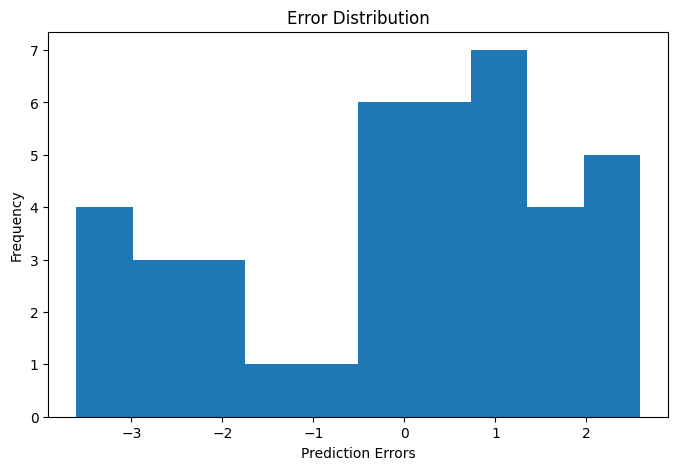

In [39]:
#error analysis
errors = y_test_m - y_pred_multiple

plt.figure(figsize=(8,5))

plt.hist(errors, bins=10)

plt.xlabel("Prediction Errors")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

In [40]:
# coefficients and intercept
print("\nIntercept:", multiple_model.intercept_)

coeff_df = pd.DataFrame({
    'Feature': X_multiple.columns,
    'Coefficient': multiple_model.coef_
})

print("\nCoefficients:\n")
print(coeff_df)


Intercept: 2.979067338122629

Coefficients:

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


## Final Outcome
Built Simple and Multiple Linear Regression models
Predicted sales values
Visualized regression line
Evaluated using:
Mean Squared Error (MSE)
R² Score
## Understood predictive modeling practically
Expected Insights
✅ TV advertising strongly impacts sales
✅ Multiple regression performs better than simple regression
✅ Lower MSE indicates better predictions
✅ Higher R² means better model fit